# 🌸 Iris Species Classification
**Task 1 
Dataset: [Iris Classification Dataset](https://www.kaggle.com/datasets/bhanupratapbiswas/iris-classification-dataset)  

---
### Objective
Build and compare classification models (k-NN, Logistic Regression, Decision Tree) to predict Iris species from sepal/petal measurements.

**Table of Contents**
1. [Setup & Imports](#1-setup)
2. [Load & Inspect Dataset](#2-load)
3. [Exploratory Data Analysis](#3-eda)
4. [Feature Preprocessing & Train-Test Split](#4-preprocessing)
5. [Model Training](#5-training)
6. [Evaluation — Accuracy, Confusion Matrix, Precision/Recall](#6-evaluation)
7. [Model Comparison](#7-comparison)
8. [Save Best Model & Inference](#8-save)


## 1. Setup & Imports

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, precision_score, recall_score, f1_score)
from sklearn.pipeline import Pipeline
import joblib, warnings
warnings.filterwarnings('ignore')

PALETTE = {'Iris-setosa': '#4C72B0', 'Iris-versicolor': '#DD8452', 'Iris-virginica': '#55A868'}
FEATURES = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
TARGET   = 'species'
print("All libraries imported successfully ✓")

All libraries imported successfully ✓


## 2. Load & Inspect Dataset

In [17]:
df = pd.read_csv('IRIS.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (150, 5)

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [18]:
print("=== Dataset Info ===")
df.info()
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Class Distribution ===")
print(df[TARGET].value_counts())
print("\n=== Statistical Summary ===")
df.describe().round(3)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

=== Missing Values ===
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

=== Class Distribution ===
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

=== Statistical Summary ===


,sepal_length,sepal_width,petal_length,petal_width
count,150.000,150.000,150.000,150.000
mean,5.843,3.054,3.759,1.199
std,0.828,0.434,1.764,0.763
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


## 3. Exploratory Data Analysis

### 3.1 Feature Distributions (KDE + Histogram)

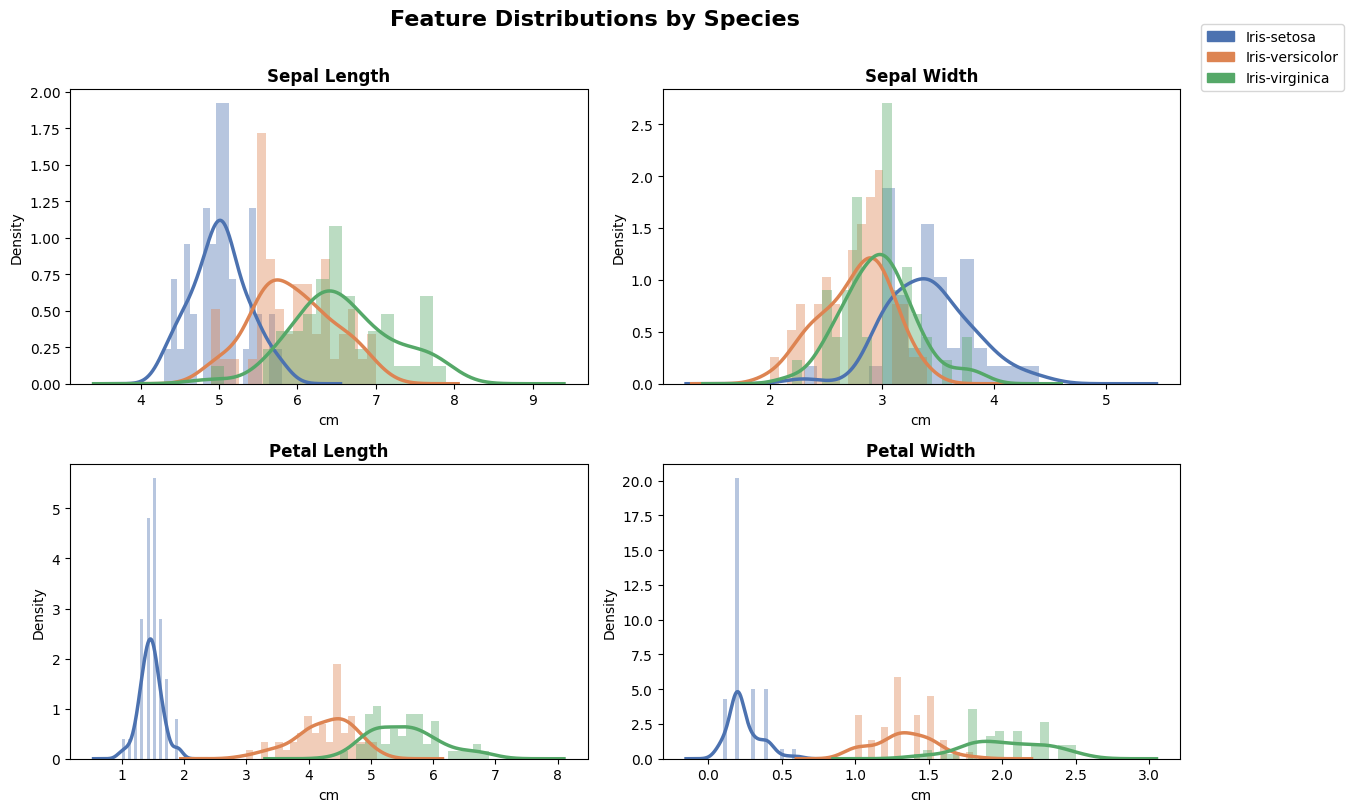

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature Distributions by Species', fontsize=16, fontweight='bold', y=1.01)
for ax, feat in zip(axes.flat, FEATURES):
    for species, grp in df.groupby(TARGET):
        grp[feat].plot.hist(ax=ax, alpha=0.4, bins=18, label=species,
                            color=PALETTE[species], density=True)
        grp[feat].plot.kde(ax=ax, color=PALETTE[species], lw=2.5)
    ax.set_title(feat.replace('_',' ').title(), fontweight='bold')
    ax.set_xlabel('cm'); ax.set_ylabel('Density')
handles = [mpatches.Patch(color=v, label=k) for k,v in PALETTE.items()]
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.13,1.0))
plt.tight_layout()
plt.show()

### 3.2 Pair-Plot — Class Separability

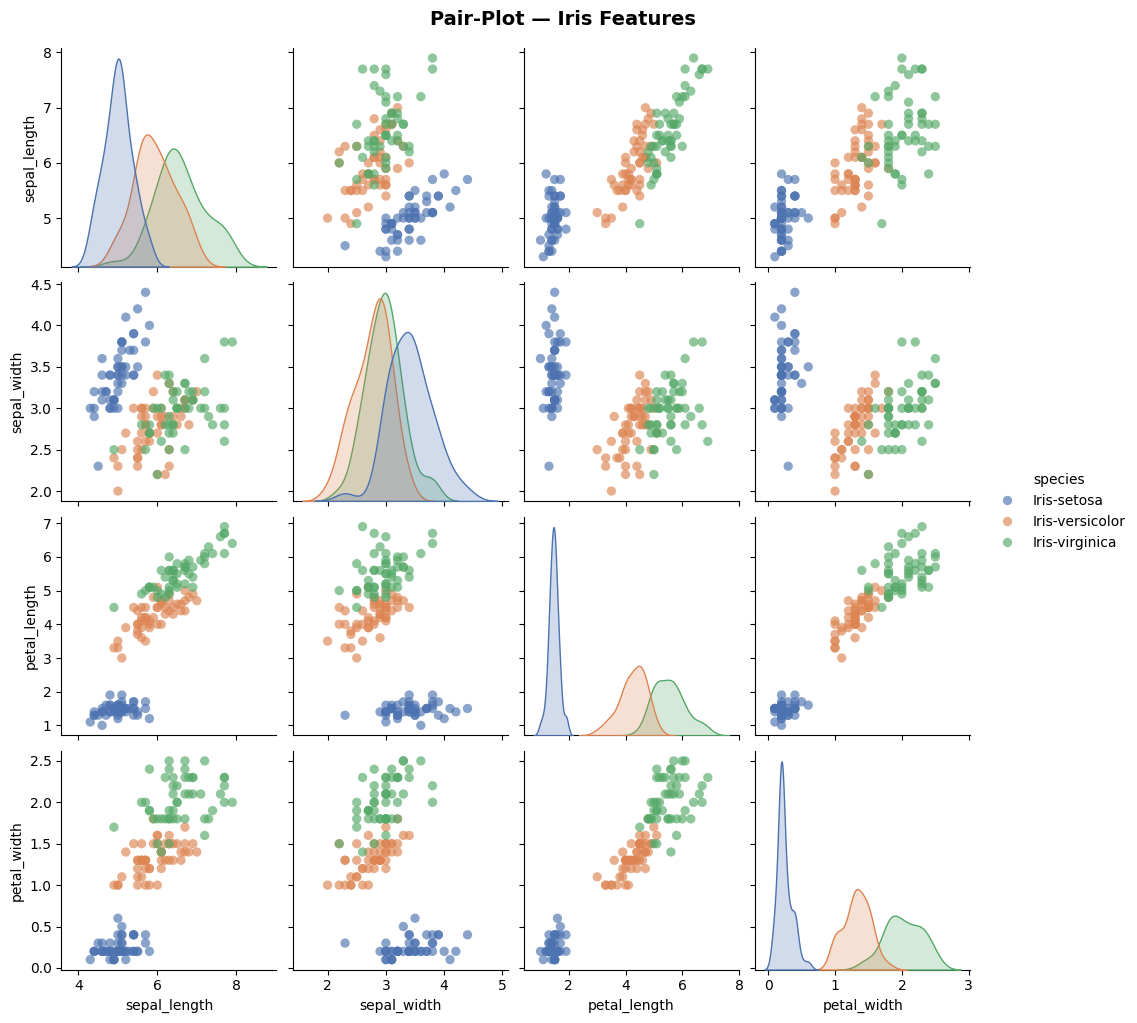

In [20]:
g = sns.pairplot(df, hue=TARGET, palette=PALETTE, diag_kind='kde',
                 plot_kws=dict(alpha=0.65, s=45, edgecolors='none'))
g.fig.suptitle('Pair-Plot — Iris Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()

### 3.3 Correlation Heatmap

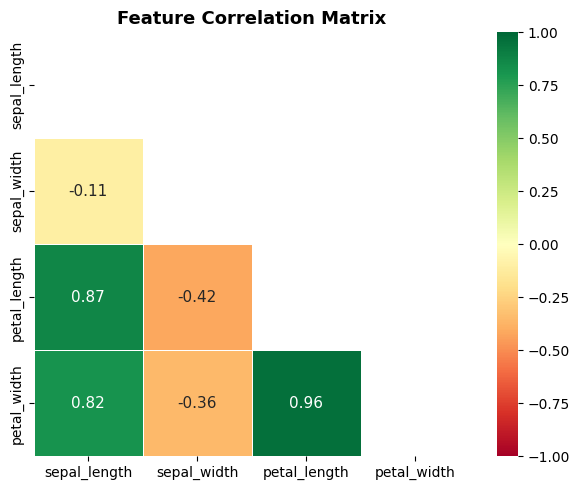

Key insight: petal_length & petal_width are highly correlated (r ≈ 0.96)


In [21]:
fig, ax = plt.subplots(figsize=(6,5))
corr = df[FEATURES].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=np.triu(np.ones_like(corr, dtype=bool)),
            linewidths=0.5, ax=ax, vmin=-1, vmax=1, annot_kws={'size':11})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print("Key insight: petal_length & petal_width are highly correlated (r ≈ 0.96)")

### 3.4 Box-Plots — Outlier Check

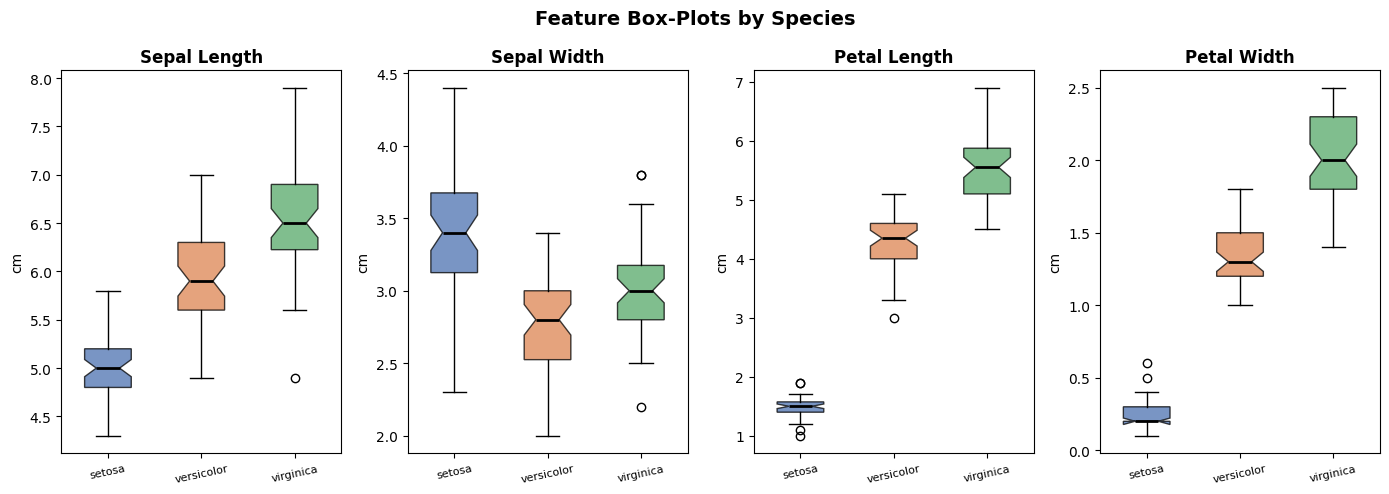

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
fig.suptitle('Feature Box-Plots by Species', fontsize=14, fontweight='bold')
for ax, feat in zip(axes, FEATURES):
    data_groups = [df[df[TARGET]==s][feat].values for s in PALETTE]
    bp = ax.boxplot(data_groups, patch_artist=True, notch=True, widths=0.5,
                    medianprops=dict(color='black', lw=2))
    for patch, color in zip(bp['boxes'], PALETTE.values()):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_xticklabels(['setosa','versicolor','virginica'], rotation=12, fontsize=8)
    ax.set_title(feat.replace('_',' ').title(), fontweight='bold')
    ax.set_ylabel('cm')
plt.tight_layout(); plt.show()

## 4. Feature Preprocessing & Train-Test Split

In [23]:
X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train samples : {len(X_train)}")
print(f"Test  samples : {len(X_test)}")
print(f"Train class counts: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test  class counts: {dict(zip(*np.unique(y_test,  return_counts=True)))}")

Train samples : 120
Test  samples : 30
Train class counts: {'Iris-setosa': np.int64(40), 'Iris-versicolor': np.int64(40), 'Iris-virginica': np.int64(40)}
Test  class counts: {'Iris-setosa': np.int64(10), 'Iris-versicolor': np.int64(10), 'Iris-virginica': np.int64(10)}


## 5. Model Training

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'K-Nearest Neighbours': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression':  LogisticRegression(max_iter=300, random_state=42),
    'Decision Tree':        DecisionTreeClassifier(max_depth=4, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred    = model.predict(X_test_s)
    cv_scores = cross_val_score(model, X_train_s, y_train, cv=cv, scoring='accuracy')
    results[name] = {
        'model':     model, 'y_pred': y_pred,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall':    recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1':        f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'cv_mean':   cv_scores.mean(), 'cv_std': cv_scores.std(),
    }
    print(f"✓ {name} trained")
print("\nAll models trained!")

✓ K-Nearest Neighbours trained
✓ Logistic Regression trained
✓ Decision Tree trained

All models trained!


## 6. Evaluation

### 6.1 Classification Reports

In [25]:
for name, res in results.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print('='*55)
    print(classification_report(y_test, res['y_pred']))


  K-Nearest Neighbours
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30


  Logistic Regression
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30


  Decision Tree
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor  

### 6.2 Confusion Matrices

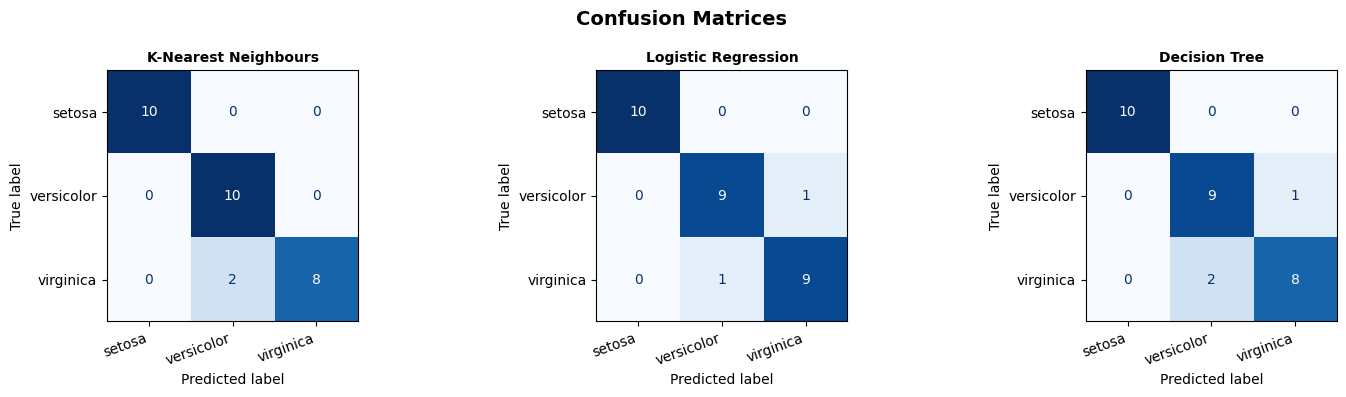

In [26]:
classes = np.unique(y)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'], labels=classes)
    ConfusionMatrixDisplay(cm, display_labels=['setosa','versicolor','virginica']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xticklabels(['setosa','versicolor','virginica'], rotation=20, ha='right')
plt.tight_layout(); plt.show()

## 7. Model Comparison

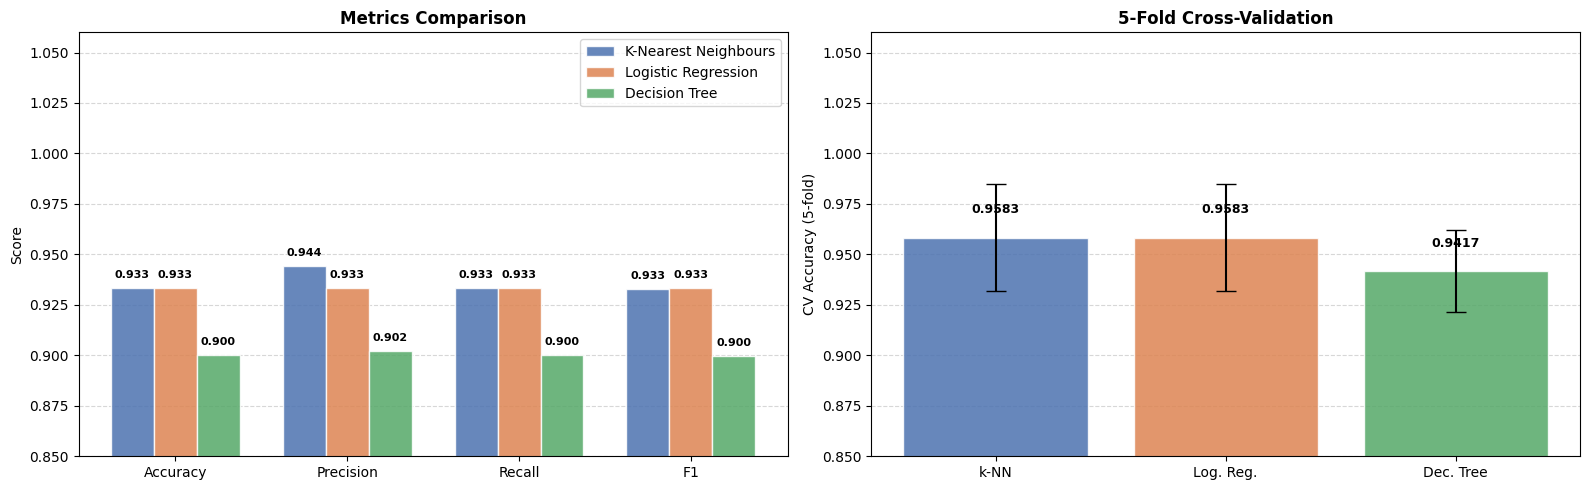


📊 Summary Table:
                      accuracy  precision  recall      f1  cv_mean  cv_std
K-Nearest Neighbours    0.9333     0.9444  0.9333  0.9327   0.9583  0.0264
Logistic Regression     0.9333     0.9333  0.9333  0.9333   0.9583  0.0264
Decision Tree           0.9000     0.9024  0.9000  0.8997   0.9417  0.0204


In [27]:
metrics = ['accuracy','precision','recall','f1']
labels  = list(results.keys())
x, width = np.arange(len(metrics)), 0.25
bar_colors = ['#4C72B0','#DD8452','#55A868']
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
ax = axes[0]
for i, (name, res) in enumerate(results.items()):
    vals = [res[m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=name,
                  color=bar_colors[i], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(x + width); ax.set_xticklabels([m.title() for m in metrics])
ax.set_ylim(0.85, 1.06); ax.set_ylabel('Score')
ax.set_title('Metrics Comparison', fontsize=12, fontweight='bold')
ax.legend(); ax.yaxis.grid(True, linestyle='--', alpha=0.5); ax.set_axisbelow(True)

# CV scores
ax2 = axes[1]
cv_means = [results[n]['cv_mean'] for n in labels]
cv_stds  = [results[n]['cv_std']  for n in labels]
short = ['k-NN','Log. Reg.','Dec. Tree']
bars2 = ax2.bar(short, cv_means, color=bar_colors, alpha=0.85,
               yerr=cv_stds, capsize=7, edgecolor='white')
for bar, v in zip(bars2, cv_means):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.012,
             f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)
ax2.set_ylim(0.85, 1.06); ax2.set_ylabel('CV Accuracy (5-fold)')
ax2.set_title('5-Fold Cross-Validation', fontsize=12, fontweight='bold')
ax2.yaxis.grid(True, linestyle='--', alpha=0.5); ax2.set_axisbelow(True)

plt.tight_layout(); plt.show()

print("\n📊 Summary Table:")
summary_df = pd.DataFrame({
    name: {m: round(res[m],4) for m in ['accuracy','precision','recall','f1','cv_mean','cv_std']}
    for name, res in results.items()
}).T
print(summary_df.to_string())

### 7.1 Decision Tree Visualisation

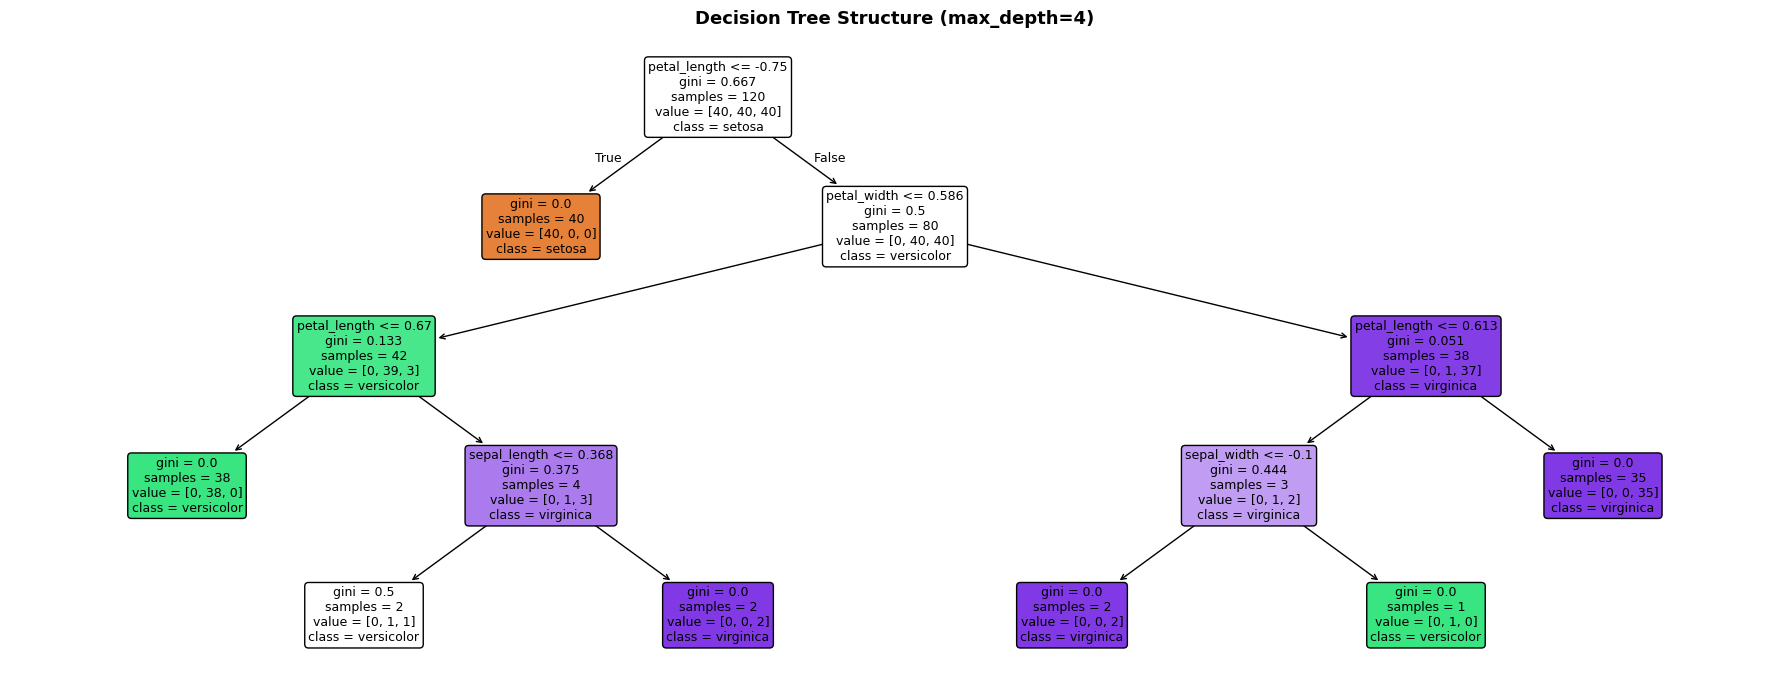

In [28]:
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(results['Decision Tree']['model'],
          feature_names=FEATURES,
          class_names=['setosa','versicolor','virginica'],
          filled=True, rounded=True, fontsize=9, ax=ax, impurity=True)
ax.set_title('Decision Tree Structure (max_depth=4)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 8. Save Best Model & Inference Example

In [ ]:
best_name  = max(results, key=lambda n: results[n]['accuracy'])
best_model = results[best_name]['model']
print(f"🏆 Best Model  : {best_name}")
print(f"   Accuracy    : {results[best_name]['accuracy']:.4f}")
print(f"   CV Accuracy : {results[best_name]['cv_mean']:.4f} ± {results[best_name]['cv_std']:.4f}")

pipeline = Pipeline([('scaler', scaler), ('clf', best_model)])
joblib.dump(pipeline, 'Iris_best_model.pkl')
print("\n✅ Model saved as: Iris_best_model.pkl")

🏆 Best Model  : K-Nearest Neighbours
   Accuracy    : 0.9333
   CV Accuracy : 0.9583 ± 0.0264

✅ Model saved as: iris_best_model.pkl


### Inference Example

In [ ]:
# ─── Inference example (run this anywhere) ────────────────────────────────
import joblib
import numpy as np

# Load the saved pipeline (scaler + classifier)
pipeline = joblib.load('Iris_best_model.pkl')

# New sample: [sepal_length, sepal_width, petal_length, petal_width]  (in cm)
sample = np.array([[5.1, 3.5, 1.4, 0.2]])   # typical Iris-setosa

prediction  = pipeline.predict(sample)
probabilities = pipeline.predict_proba(sample)

print(f"Predicted species : {prediction[0]}")
print(f"Class probabilities:")
for cls, prob in zip(pipeline.classes_, probabilities[0]):
    print(f"  {cls:<20} {prob:.4f}")

Predicted species : Iris-setosa
Class probabilities:
  Iris-setosa          1.0000
  Iris-versicolor      0.0000
  Iris-virginica       0.0000
